# ASSIGNMENT NLP – 4 (BERT Fine-Tuning)


## Import Required Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from tqdm import tqdm

import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader

import warnings
warnings.filterwarnings('ignore')

## 1. Data Preprocessing


In [2]:
imdb = pd.read_csv('IMDB Dataset.csv', engine='python')
imdb.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
imdb.info()
imdb['sentiment'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


,count
sentiment,
positive,25000
negative,25000


In [4]:
imdb.isnull().sum()

,0
review,0
sentiment,0


In [5]:
def clean_text(text):
  text = text.lower()
  text = re.sub(r'http\S+', '', text)
  text = re.sub(r'<.*?>', '', text)
  text = re.sub(r'\d+', '', text)
  text = re.sub(r'\s+', ' ', text)
  text = re.sub(r'\b\w{1,2}\b', '', text)
  text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
  return text

imdb['review'] = imdb['review'].apply(clean_text)

In [6]:
imdb.head()

,review,sentiment
0,one the other reviewers has mentioned that af...,positive
1,wonderful little production the filming techn...,positive
2,thought this was wonderful way spend time ...,positive
3,basically there family where little boy jake...,negative
4,petter mattei love the time money visually...,positive


In [7]:
## Label Encoding
imdb['label'] = imdb['sentiment'].map({'positive':1, 'negative':0})
imdb.head()

,review,sentiment,label
0,one the other reviewers has mentioned that af...,positive,1
1,wonderful little production the filming techn...,positive,1
2,thought this was wonderful way spend time ...,positive,1
3,basically there family where little boy jake...,negative,0
4,petter mattei love the time money visually...,positive,1


## 2. Data Splitting


In [8]:
train_texts, temp_texts, train_label, temp_label = train_test_split(imdb['review'], imdb['label'], test_size=0.3, random_state=42)
test_texts, val_texts, test_label, val_label = train_test_split(temp_texts, temp_label, test_size=0.5, random_state=42)

## 3. Tokenization


In [9]:
# Using bert-base-uncased tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
# Converting text to tokens

train_encodings =  tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)

In [11]:
class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [12]:
train_dataset = IMDbDataset(train_encodings, train_label)
val_dataset = IMDbDataset(val_encodings, val_label)
test_dataset = IMDbDataset(test_encodings, test_label)

## 4. Model Building

In [13]:
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 5. Fine-Tuning

In [14]:
optimizer = AdamW(model.parameters(), lr = 2e-5)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

## 6. Model Training and Evaluation

In [16]:
EPOCHS = 3

for epoch in range(EPOCHS):
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    # ================= TRAINING =================
    model.train()
    total_train_loss = 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids,attention_mask=attention_mask,labels=labels)

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_train_loss = total_train_loss / len(train_loader)
    print(f"Train Loss: {avg_train_loss:.4f}")

    # ================= VALIDATION =================
    model.eval()
    total_val_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids,attention_mask=attention_mask,labels=labels)

            loss = outputs.loss
            logits = outputs.logits

            total_val_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    print(f"Validation Loss: {avg_val_loss:.4f}")

    # ================= METRICS =================
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")


===== Epoch 1/3 =====


100%|██████████| 2188/2188 [15:05<00:00,  2.42it/s]


Train Loss: 0.3030


100%|██████████| 469/469 [01:06<00:00,  7.06it/s]


Validation Loss: 0.2610
Accuracy: 0.8893
Precision: 0.9197
Recall: 0.8549
F1 Score: 0.8861

===== Epoch 2/3 =====


...

Validation Loss: 0.2844
Accuracy: 0.8915
Precision: 0.9227
Recall: 0.8563
F1 Score: 0.8882

===== Epoch 3/3 =====


100%|██████████| 2188/2188 [15:19<00:00,  2.38it/s]


Train Loss: 0.0879


100%|██████████| 469/469 [01:06<00:00,  7.06it/s]

Validation Loss: 0.3537
Accuracy: 0.8928
Precision: 0.9172
Recall: 0.8653
F1 Score: 0.8905


## Perfoming Experiments

In [17]:
def run_experiment(exp_name, freeze_type):

    print(f"\n===== Running {exp_name} =====")

    # Reinitialize model (MANDATORY)
    model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    )
    model.to(device)

    # Apply freezing strategy
    if freeze_type == "frozen":
        for param in model.bert.parameters():
            param.requires_grad = False

    elif freeze_type == "last2":
        for name, param in model.bert.named_parameters():
            if "encoder.layer.10" in name or "encoder.layer.11" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

    elif freeze_type == "full":
        for param in model.parameters():
            param.requires_grad = True

    # Optimizer
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

    EPOCHS = 3

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        # ================= TRAIN =================
        model.train()
        total_train_loss = 0

        for batch in tqdm(train_loader):
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()

        print(f"Train Loss: {total_train_loss / len(train_loader):.4f}")

        # ================= VALIDATION =================
        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                logits = outputs.logits
                preds = torch.argmax(logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    # ================= FINAL METRICS =================
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='binary'
    )

    print(f"\n{exp_name} Results:")
    print(f"Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

    return {
        "Experiment": exp_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [18]:
results = []

results.append(run_experiment("Frozen BERT", "frozen"))
results.append(run_experiment("Last 2 Layers", "last2"))
results.append(run_experiment("Full Fine-Tuning", "full"))


===== Running Frozen BERT =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Epoch 1/3


100%|██████████| 2188/2188 [05:18<00:00,  6.87it/s]


...


Epoch 3/3


100%|██████████| 2188/2188 [15:21<00:00,  2.37it/s]


Train Loss: 0.0923


100%|██████████| 469/469 [01:06<00:00,  7.06it/s]


Full Fine-Tuning Results:
Accuracy: 0.8935, Precision: 0.8764, Recall: 0.9179, F1: 0.8967


In [19]:
# Comparing Results
results_compare = pd.DataFrame(results)
print(results_compare)

,Experiment,Accuracy,Precision,Recall,F1
0,Frozen BERT,0.696267,0.665198,0.799365,0.726136
1,Last 2 Layers,0.879733,0.903933,0.851773,0.877078
2,Full Fine-Tuning,0.893467,0.876422,0.917946,0.896703


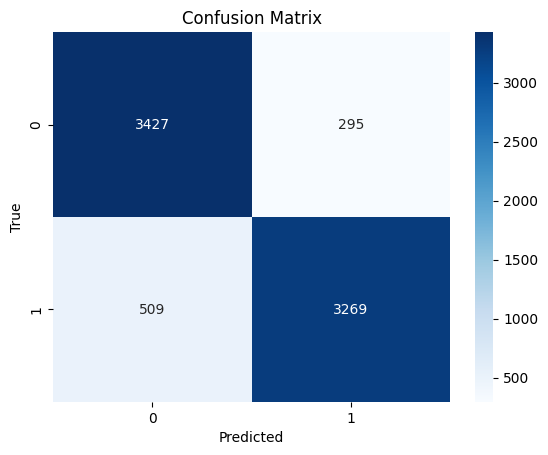

              precision    recall  f1-score   support

           0       0.87      0.92      0.90      3722
           1       0.92      0.87      0.89      3778

    accuracy                           0.89      7500
   macro avg       0.89      0.89      0.89      7500
weighted avg       0.89      0.89      0.89      7500



In [20]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
print(classification_report(all_labels, all_preds))